In [4]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from processing import crop_faces
from training import (
    CROPS_DIR, BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, VAL_SPLIT, SEED, CHECKPOINT_PATH,
    get_device, build_dataloaders, compute_class_weights, build_model, run_epoch,
)
from evaluation import evaluate_model


## 1. Build the crops dataset

In [ ]:
crop_faces(
    image_dir="../data/images",
    annotation_dir="../data/annotations",
    output_dir="../data/crops",
)


## 2. Train

In [8]:
device = get_device()
print(f"Using device: {device}")

train_loader, val_loader, classes, train_targets = build_dataloaders(CROPS_DIR, BATCH_SIZE, VAL_SPLIT, SEED)
print(f"Classes: {classes}")

class_weights = compute_class_weights(train_targets, len(classes)).to(device)
print(f"Class weights: {class_weights.tolist()}")

model = build_model(len(classes)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


Using device: mps
Classes: ['mask_weared_incorrect', 'with_mask', 'without_mask']
Class weights: [10.11228084564209, 0.4174996316432953, 1.9766803979873657]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/leh20/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:09<00:00, 4.88MB/s]


In [9]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved new best model (val acc {val_acc:.4f})")

print(f"Training done. Best val accuracy: {best_val_acc:.4f}")


Epoch 1/15 | train loss 0.5643 acc 0.7641 | val loss 0.4238 acc 0.9196
  Saved new best model (val acc 0.9196)
Epoch 2/15 | train loss 0.1872 acc 0.9389 | val loss 0.4500 acc 0.9362
  Saved new best model (val acc 0.9362)
Epoch 3/15 | train loss 0.1343 acc 0.9656 | val loss 0.6619 acc 0.9487
  Saved new best model (val acc 0.9487)
Epoch 4/15 | train loss 0.0828 acc 0.9698 | val loss 0.4536 acc 0.9570
  Saved new best model (val acc 0.9570)
Epoch 5/15 | train loss 0.0358 acc 0.9910 | val loss 0.5726 acc 0.9681
  Saved new best model (val acc 0.9681)
Epoch 6/15 | train loss 0.0256 acc 0.9944 | val loss 0.4922 acc 0.9639
Epoch 7/15 | train loss 0.0109 acc 0.9976 | val loss 0.6212 acc 0.9764
  Saved new best model (val acc 0.9764)
Epoch 8/15 | train loss 0.0124 acc 0.9965 | val loss 0.5181 acc 0.9736
Epoch 9/15 | train loss 0.0131 acc 0.9976 | val loss 0.5096 acc 0.9736
Epoch 10/15 | train loss 0.0633 acc 0.9847 | val loss 0.5418 acc 0.9334
Epoch 11/15 | train loss 0.0947 acc 0.9747 | val 

## 3. Training curves

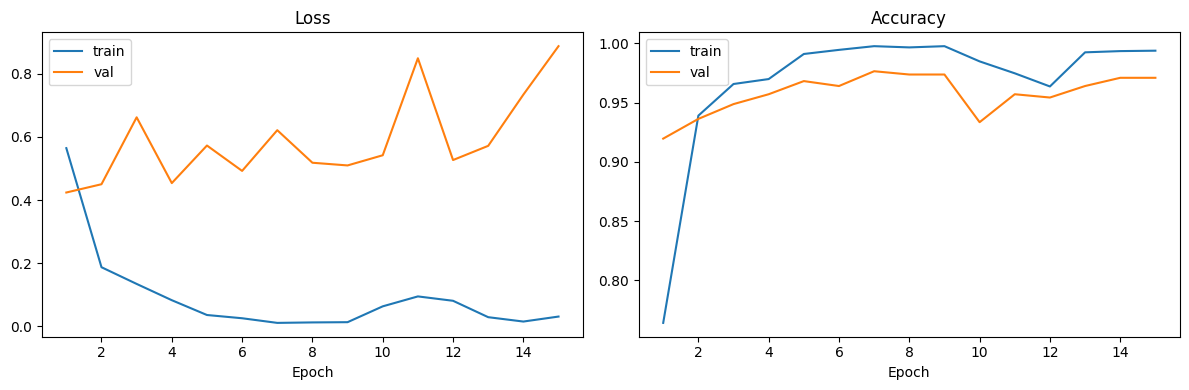

In [10]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Evaluate on validation set

Loads the best checkpoint saved during training and reports precision/recall/F1 per class.

In [11]:
results = evaluate_model()
print(results["report"])


                       precision    recall  f1-score   support

mask_weared_incorrect       0.92      0.48      0.63        23
            with_mask       0.99      0.99      0.99       576
         without_mask       0.92      1.00      0.96       122

             accuracy                           0.98       721
            macro avg       0.94      0.82      0.86       721
         weighted avg       0.98      0.98      0.97       721



## 5. Confusion matrix


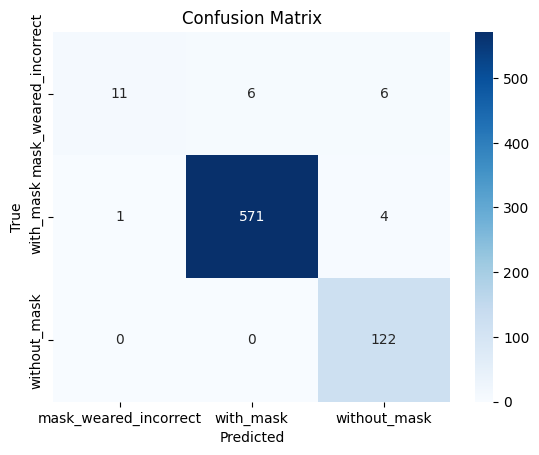

In [13]:
sns.heatmap(
    results["confusion_matrix"], annot=True, fmt="d",
    xticklabels=results["classes"], yticklabels=results["classes"], cmap="Blues",
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
